# dod2k analysis notebook: SPELEOTHEM records only

__Authors:__ 
<br>__Last edited:_
<br>__Modified from code by:__ Lucie Luecke



## Set up working environment

Make sure the repo_root is added correctly, it should be: ```your_root_dir/dod2k```
This should be the working directory throughout this notebook (and all other notebooks).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
from pathlib import Path

# Add parent directory to path (works from any notebook in notebooks/)
# the repo_root should be the parent directory of the notebooks folder
init_dir = Path().resolve()
# Determine repo root
if init_dir.name == 'dod2k': repo_root = init_dir
elif init_dir.parent.name == 'dod2k': repo_root = init_dir.parent
else: raise Exception('Please review the repo root structure (see first cell).')

# Update cwd and path only if needed
if os.getcwd() != str(repo_root):
    os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"Repo root: {repo_root}")
if str(os.getcwd())==str(repo_root):
    print(f"Working directory matches repo root. ")

Repo root: C:\Users\aegir\OneDrive\Documents\PaleoCoLab\dod2k
Working directory matches repo root. 


In [2]:
# Import packages
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray
from tqdm import tqdm
import psm
import statsmodels.api as sm
import scipy

from dod2k_utilities import ut_functions as utf # contains utility functions
from dod2k_utilities import ut_plot as uplt # contains plotting functions
from dod2k_utilities import ut_analysis as uta # contains plotting functions

## Read dataframe

Read compact dataframe.

{db_name} refers to the database, including 

    - dod2k_v2.0
    
All compact dataframes are saved in {repo_root}/data/{db_name} as {db_name}_compact.csv.

In [5]:
# read dataframe, choose from the list below, or specify your own

db_name = 'dod2k_v2.0'

# load dataframe
orig_df = utf.load_compact_dataframe_from_csv(db_name)
print(orig_df.info())
orig_df.name = db_name


<class 'pandas.DataFrame'>
RangeIndex: 4957 entries, 0 to 4956
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   archiveType                    4957 non-null   str    
 1   dataSetName                    4957 non-null   str    
 2   datasetId                      4957 non-null   str    
 3   duplicateDetails               4957 non-null   str    
 4   geo_meanElev                   4875 non-null   float32
 5   geo_meanLat                    4957 non-null   float32
 6   geo_meanLon                    4957 non-null   float32
 7   geo_siteName                   4957 non-null   str    
 8   interpretation_direction       4957 non-null   str    
 9   interpretation_seasonality     4957 non-null   str    
 10  interpretation_variable        4957 non-null   str    
 11  interpretation_variableDetail  4957 non-null   str    
 12  originalDataURL                4957 non-null   str    
 13 

## Filter dataframe for speleothem type records

In [14]:
print(orig_df["archiveType"].unique)

<bound method Series.unique of 0                 Wood
1                 Wood
2                 Wood
3                 Wood
4                 Wood
             ...      
4952        Speleothem
4953        Speleothem
4954        Speleothem
4955    MarineSediment
4956              Wood
Name: archiveType, Length: 4957, dtype: str>


In [15]:
# Filter for desired data, in this case, speleothem calcite oxygen isotope measurements from the years min_year to max_year
filtered_df = orig_df.loc[(orig_df["archiveType"] == "Wood")]

# Filter data for time series that include records from or past the year 1960 AD
min_year = 0 # Inclusive
max_year = 2020 # Exclusive

#  data ranges from min to max- pick data to match the same timeframe
filtered_df = filtered_df.loc[orig_df["year"].apply(lambda x: np.max(x) >= min_year and np.min(x) < max_year)] #exclude post 2005 data
filtered_df.reset_index(inplace = True)

# Filter the filtered records for data in the correct timeframe
new_year = []
new_values = []
# For every row, apply above time conditions
for i in range (0, len(filtered_df)):
    index = np.where(filtered_df.iloc[i]["year"] >= min_year)
    new_year.append(filtered_df.iloc[i]["year"][index]) # Adds values to lists
    new_values.append(filtered_df.iloc[i]["paleoData_values"][index])
filtered_df["year"] = new_year # Create a dataframe with the filtered data lists populating it
filtered_df["paleoData_values"] = new_values
filtered_df.info()

filtered_df.name = 'dod2k_v2.0_Wood'

print(filtered_df.name)

<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   index                          3650 non-null   int64  
 1   archiveType                    3650 non-null   str    
 2   dataSetName                    3650 non-null   str    
 3   datasetId                      3650 non-null   str    
 4   duplicateDetails               3650 non-null   str    
 5   geo_meanElev                   3606 non-null   float32
 6   geo_meanLat                    3650 non-null   float32
 7   geo_meanLon                    3650 non-null   float32
 8   geo_siteName                   3650 non-null   str    
 9   interpretation_direction       3650 non-null   str    
 10  interpretation_seasonality     3650 non-null   str    
 11  interpretation_variable        3650 non-null   str    
 12  interpretation_variableDetail  3650 non-null   str    
 13 

In [23]:
#%% check data extraction for proxy_type and archive_type
proxy_types   = filtered_df['paleoData_proxy'].unique()
archive_types = filtered_df['archiveType'].unique()
calcite_types = filtered_df['paleoData_notes'].unique()

print('Proxy type: ', proxy_types)
print('Archive type: ', archive_types)
trw_df = filtered_df.loc[(filtered_df["paleoData_proxy"] == "ring width")]
print(len(trw_df))
filtered_df.head()
# should give only ['d18O'], ['speleothem'], ['calcite']

Proxy type:  <StringArray>
[              'ring width',      'residual chronology',
                   'ARSTAN', 'maximum latewood density',
              'reflectance',                     'd18O',
     'humidification index']
Length: 7, dtype: str
Archive type:  <StringArray>
['Wood']
Length: 1, dtype: str
3159


,index,archiveType,dataSetName,datasetId,duplicateDetails,geo_meanElev,geo_meanLat,geo_meanLon,geo_siteName,interpretation_direction,...,originalDataURL,originalDatabase,paleoData_notes,paleoData_proxy,paleoData_sensorSpecies,paleoData_units,paleoData_values,paleoData_variableName,year,yearUnits
0,0,Wood,NAm-MtLemon.Briffa.2002,pages2k_5,N/A,2700.0,32.5,-110.800003,Mt. Lemon,None,...,https://www1.ncdc.noaa.gov/pub/data/paleo/page...,PAGES 2k v2.2.0,nan,ring width,PSME,cm,"[2.76, 2.91, 1.88, 2.51, 2.5, 1.79, 0.915, 0.6...",ring width,"[1568.0, 1569.0, 1570.0, 1571.0, 1572.0, 1573....",CE
1,1,Wood,NAm-MtLemon.Briffa.2002,pages2k_7,N/A,2700.0,32.5,-110.800003,Mt. Lemon,None,...,https://www1.ncdc.noaa.gov/pub/data/paleo/page...,PAGES 2k v2.2.0,nan,residual chronology,PSME,nan,"[1.116, 1.152, 0.768, 1.151, 1.075, 0.811, 0.7...",residual chronology,"[1568.0, 1569.0, 1570.0, 1571.0, 1572.0, 1573....",CE
2,2,Wood,NAm-MtLemon.Briffa.2002,pages2k_8,N/A,2700.0,32.5,-110.800003,Mt. Lemon,None,...,https://www1.ncdc.noaa.gov/pub/data/paleo/page...,PAGES 2k v2.2.0,nan,ARSTAN,PSME,nan,"[1.143, 1.223, 0.876, 1.1, 1.126, 0.874, 0.679...",ARSTAN,"[1568.0, 1569.0, 1570.0, 1571.0, 1572.0, 1573....",CE
3,3,Wood,NAm-MtLemon.Briffa.2002,pages2k_18,N/A,2700.0,32.5,-110.800003,Mt. Lemon,None,...,https://www1.ncdc.noaa.gov/pub/data/paleo/page...,PAGES 2k v2.2.0,nan,maximum latewood density,PSME,g/cm3,"[0.85, 0.84, 0.92, 0.82, 0.91, 0.82, 0.875, 0....",maximum latewood density,"[1568.0, 1569.0, 1570.0, 1571.0, 1572.0, 1573....",CE
4,4,Wood,NAm-MtLemon.Briffa.2002,pages2k_19,N/A,2700.0,32.5,-110.800003,Mt. Lemon,positive,...,https://www1.ncdc.noaa.gov/pub/data/paleo/page...,PAGES 2k v2.2.0,nan,maximum latewood density,PSME,nan,"[0.968, 0.962, 1.013, 0.95, 1.008, 0.952, 1.02...",maximum latewood density,"[1568.0, 1569.0, 1570.0, 1571.0, 1572.0, 1573....",CE


### Plot data

saved figure in C:\Users\aegir\OneDrive\Documents\PaleoCoLab\dod2k/figs/TRW/geo_TRW.pdf


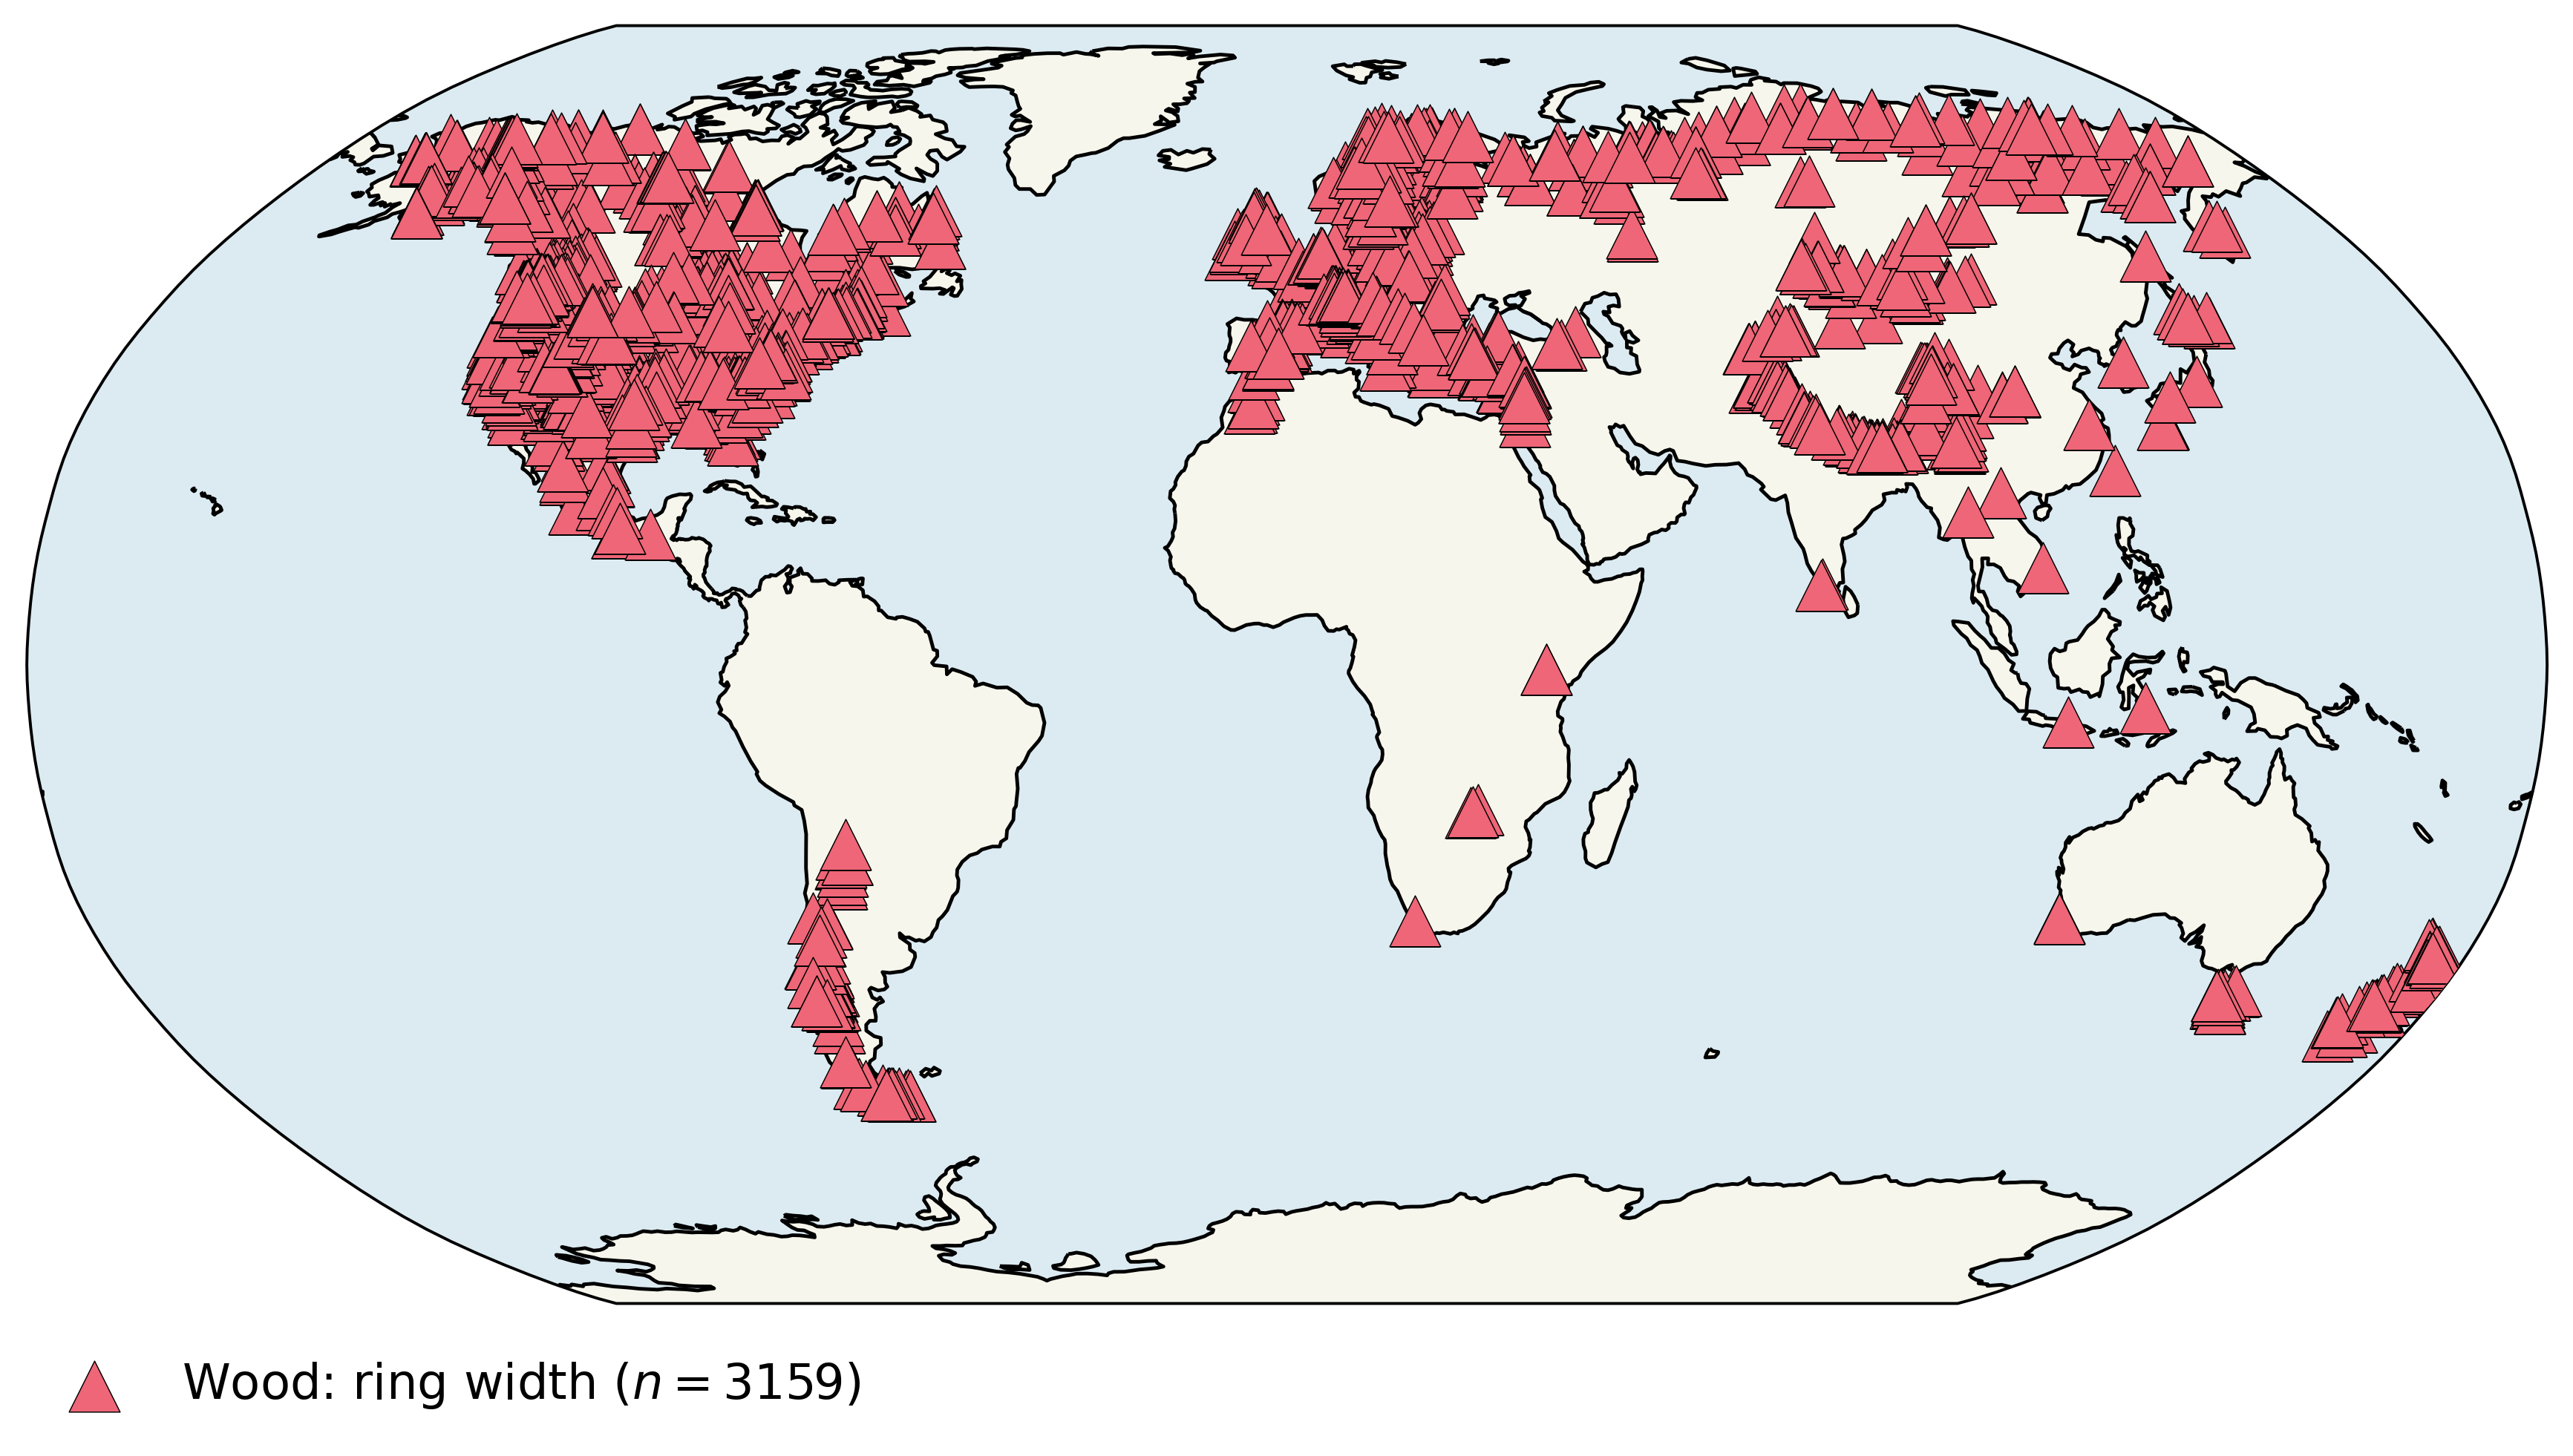

In [30]:
# count archive types
trw_df.name = "TRW"
archive_count = {}
for ii, at in enumerate(set(trw_df['archiveType'])):
    archive_count[at] = trw_df.loc[trw_df['archiveType']==at, 'archiveType'].count()

sort = np.argsort([cc for cc in archive_count.values()])
archives_sorted = np.array([cc for cc in archive_count.keys()])[sort][::-1]

fig = uplt.plot_geo_archive_proxy(trw_df, {'Wood':'#EE6677'}, marker='^', figsize=(13/1.3, 8/1.3))
utf.save_fig(fig, f'geo_{trw_df.name}', dir=trw_df.name)

saved figure in C:\Users\aegir\OneDrive\Documents\PaleoCoLab\dod2k/figs/TRW/time_TRW.pdf


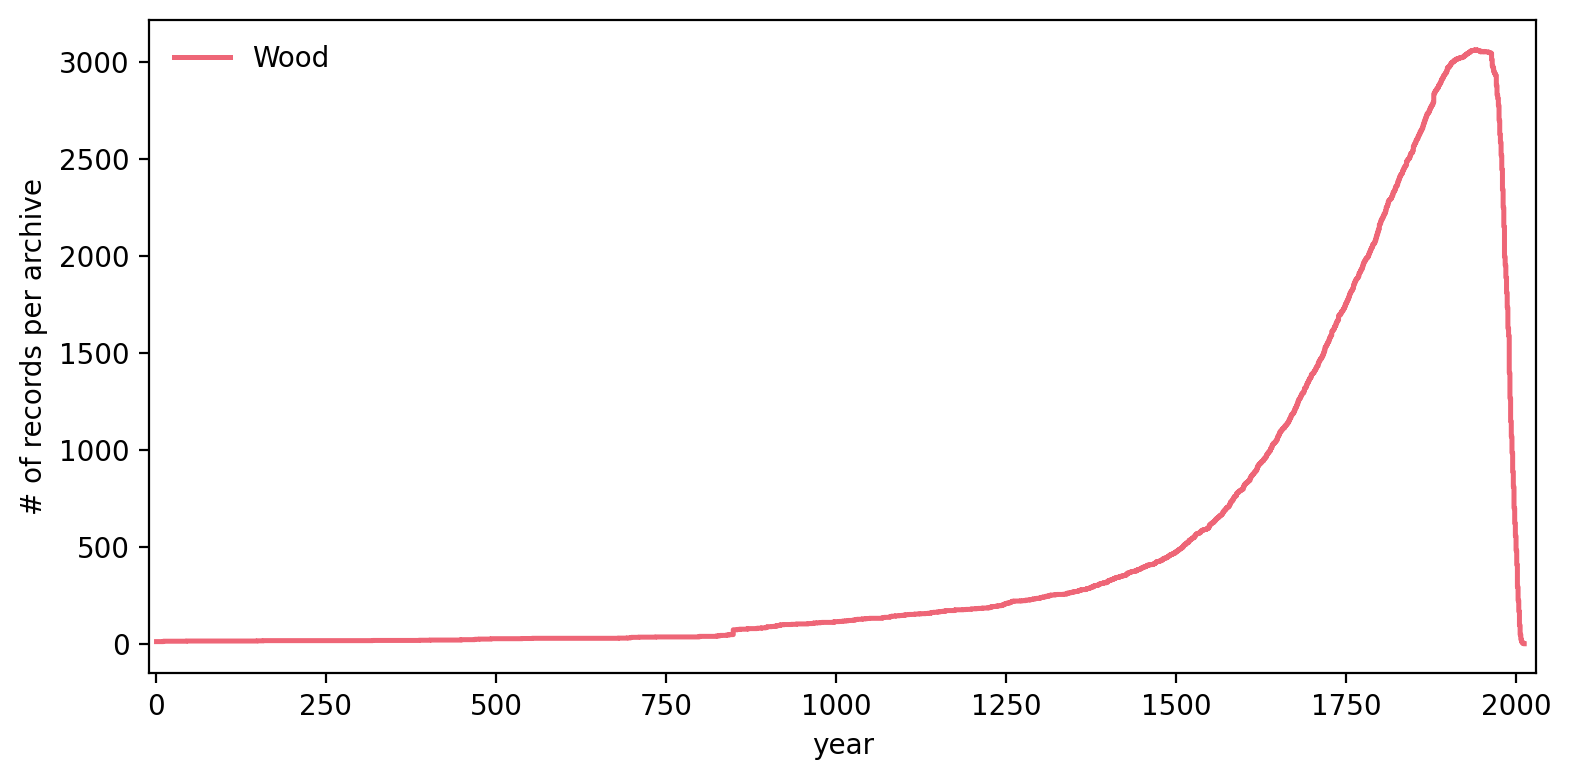

In [33]:
fig = uplt.plot_coverage(trw_df, archives_sorted, ['Wood'], [], {'Wood':'#EE6677'})
plt.xlim(min_year-10, max_year+10)
utf.save_fig(fig, f'time_{trw_df.name}', dir=trw_df.name)

## save relevant data for speleothem analysis

In [8]:
# Choose relevant data for simulation comparison
df = filtered_df[['geo_meanLat', 'geo_meanLon', 'paleoData_values']]

# extract average of paleoData_values
df.loc[:,'paleoData_values'] = df.loc[:,'paleoData_values'].apply(np.average)

# create directory for speleo modeling inputs
os.makedirs('data/speleo_modeling', exist_ok=True)
df.to_csv('data/speleo_modeling/df_dod2k_speleo_analysis.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   geo_meanLat       61 non-null     float32
 1   geo_meanLon       61 non-null     float32
 2   paleoData_values  61 non-null     object 
dtypes: float32(2), object(1)
memory usage: 1.1+ KB


## load observations

### load CRU TS

In [39]:
# Load temperature data, source: CRU TS 4.07 tmp
ds = xr.open_dataset('../data/speleo_modeling/cru_ts4.07.1901.2022.tmp.dat.nc.gz')

FileNotFoundError: No such file: '../data/speleo_modeling/cru_ts4.07.1901.2022.tmp.dat.nc.gz'

In [ ]:
cruT_mon = ds['tmp']

In [ ]:
#Reduce this DataArray’s data by applying mean along some dimension(s).
cruT=cruT_mon.mean(dim='time')
print(cruT)

<xarray.DataArray 'tmp' (lat: 360, lon: 720)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75


### Load observed isotope data

In [36]:
path = 'data/speleo_modeling/GlobalPrecip/d18o_MA.tif'
d18Op_da = rioxarray.open_rasterio(path)
if d18Op_da.sizes.get("band", 1) == 1:
    d18Op_da = d18Op_da.squeeze('band', drop=True)
d18Op_da = d18Op_da.rename({'x': 'lon', 'y': 'lat'})
d18Op_da = d18Op_da.where(np.abs(d18Op_da)<1e3)  # mask NaN regions
d18Op_da.attrs['units'] = 'permil'
d18Op_da.attrs['long_name'] = 'd18Op'
d18Op_da.name = 'd18Op'
#d18Op_da

### Join data

In [38]:
# create a dataframe to hold observed o18, T,o18p, pred o18c
pred_frame = pd.DataFrame()
pred_frame['geo_meanLon'] = filtered_df['geo_meanLon']
pred_frame['geo_meanLat'] = filtered_df['geo_meanLat']
pred_frame['d18Oc_vals'] = filtered_df['paleoData_values']
pred_frame['d18Op_vals'] = object
pred_frame['cruT_vals'] = object
pred_frame['d18Ocs_vals']= object #np.zeros(len['d18Op_vals'])#object #np.nan # object # np.nan(len(['d18Op_vals']))
print(len(pred_frame['d18Ocs_vals']))

# KF: Finding nearest param data to observed data
for idx, row in tqdm(pred_frame.iterrows(), total=len(pred_frame)):
    lon = row['geo_meanLon']
    lat = row['geo_meanLat']

    # temp
    nearest_cruT = uta.find_nearest2d(cruT, lat, lon, lat_name='lat', lon_name='lon', new_dim='sites',r=6)
    if np.isnan(nearest_cruT).all():
        pred_frame.at[idx, 'cruT_vals'] = np.nan
    else:
        pred_frame.at[idx, 'cruT_vals'] = nearest_cruT.data
        #pred_frame.at[idx, 'cruT_vals'] = np.repeat(nearest_cruT.data,46)

    # d18Op
    nearest_o18p = uta.find_nearest2d(d18Op_da, lat, lon, lat_name='lat', lon_name='lon', new_dim='sites', r=6)
    if np.isnan(nearest_o18p).all():
        pred_frame.at[idx, 'd18Op_vals'] = np.nan
    else:
        pred_frame.at[idx, 'd18Op_vals'] = nearest_o18p.data
        pred_frame.at[idx, 'd18Op_vals'] = np.repeat(nearest_o18p.data,46)
        
#pred_frame
# KF: Important to note that the simulated records use data collected from sites closest to, but not always at the same location as, the observed records
# KF: This data collection is done above. Methods for finding the nearest gridpoint to an observation can be found in the functions.py file, function find_nearest2d, written by Feng Zhu

3650


  0%|          | 0/3650 [00:00<?, ?it/s]


NameError: name 'cruT' is not defined